In [1]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# # Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# # Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

# import kagglehub
# # kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
# ============================================================
# XAI-NIDS Dissertation
# NSL-KDD Dataset
# Environment and Dataset Inspection
# ============================================================

import os
import numpy as np
import pandas as pd

print("Environment initialized successfully.\n")

# Display available NSL-KDD files
for dirname, _, filenames in os.walk("/kaggle/input"):
    for filename in filenames:
        print(os.path.join(dirname, filename))

Environment initialized successfully.

/kaggle/input/datasets/hassan06/nslkdd/KDDTest+.arff
/kaggle/input/datasets/hassan06/nslkdd/KDDTest-21.arff
/kaggle/input/datasets/hassan06/nslkdd/KDDTest1.jpg
/kaggle/input/datasets/hassan06/nslkdd/KDDTrain+.txt
/kaggle/input/datasets/hassan06/nslkdd/KDDTrain+_20Percent.txt
/kaggle/input/datasets/hassan06/nslkdd/KDDTest-21.txt
/kaggle/input/datasets/hassan06/nslkdd/KDDTest+.txt
/kaggle/input/datasets/hassan06/nslkdd/KDDTrain+.arff
/kaggle/input/datasets/hassan06/nslkdd/index.html
/kaggle/input/datasets/hassan06/nslkdd/KDDTrain+_20Percent.arff
/kaggle/input/datasets/hassan06/nslkdd/KDDTrain1.jpg
/kaggle/input/datasets/hassan06/nslkdd/nsl-kdd/KDDTest+.arff
/kaggle/input/datasets/hassan06/nslkdd/nsl-kdd/KDDTest-21.arff
/kaggle/input/datasets/hassan06/nslkdd/nsl-kdd/KDDTest1.jpg
/kaggle/input/datasets/hassan06/nslkdd/nsl-kdd/KDDTrain+.txt
/kaggle/input/datasets/hassan06/nslkdd/nsl-kdd/KDDTrain+_20Percent.txt
/kaggle/input/datasets/hassan06/nslkdd/nsl

In [3]:
# ============================================================
# NSL-KDD Dataset File Inspection
# ============================================================

train_path = "/kaggle/input/datasets/hassan06/nslkdd/KDDTrain+.txt"
test_path  = "/kaggle/input/datasets/hassan06/nslkdd/KDDTest+.txt"

print("Training file exists:", os.path.exists(train_path))
print("Testing file exists :", os.path.exists(test_path))

print("\nTraining file size:")
print(f"{os.path.getsize(train_path) / (1024 * 1024):.2f} MB")

print("\nTesting file size:")
print(f"{os.path.getsize(test_path) / (1024 * 1024):.2f} MB")

print("\nFirst 3 lines of training data:\n")

with open(train_path, "r") as f:
    for _ in range(3):
        print(f.readline().strip())

Training file exists: True
Testing file exists : True

Training file size:
18.22 MB

Testing file size:
3.28 MB

First 3 lines of training data:

0,tcp,ftp_data,SF,491,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,2,0.00,0.00,0.00,0.00,1.00,0.00,0.00,150,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
0,udp,other,SF,146,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,13,1,0.00,0.00,0.00,0.00,0.08,0.15,0.00,255,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
0,tcp,private,S0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,123,6,1.00,1.00,0.00,0.00,0.05,0.07,0.00,255,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19


In [4]:
# ============================================================
# Load NSL-KDD Training and Testing Data
# ============================================================

# Column names for NSL-KDD
feature_names = [
    "duration", "protocol_type", "service", "flag",
    "src_bytes", "dst_bytes", "land", "wrong_fragment",
    "urgent", "hot", "num_failed_logins", "logged_in",
    "num_compromised", "root_shell", "su_attempted",
    "num_root", "num_file_creations", "num_shells",
    "num_access_files", "num_outbound_cmds", "is_host_login",
    "is_guest_login", "count", "srv_count", "serror_rate",
    "srv_serror_rate", "rerror_rate", "srv_rerror_rate",
    "same_srv_rate", "diff_srv_rate", "srv_diff_host_rate",
    "dst_host_count", "dst_host_srv_count",
    "dst_host_same_srv_rate", "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate", "dst_host_serror_rate",
    "dst_host_srv_serror_rate", "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate"
]

columns = feature_names + ["attack_type", "difficulty_level"]

# Load training dataset
train_df = pd.read_csv(
    train_path,
    header=None,
    names=columns
)

# Load testing dataset
test_df = pd.read_csv(
    test_path,
    header=None,
    names=columns
)

print("Training dataset shape:", train_df.shape)
print("Testing dataset shape :", test_df.shape)

print("\nTraining dataset:")
display(train_df.head())

print("\nTesting dataset:")
display(test_df.head())

Training dataset shape: (125973, 43)
Testing dataset shape : (22544, 43)

Training dataset:


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack_type,difficulty_level
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21



Testing dataset:


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack_type,difficulty_level
0,0,tcp,private,REJ,0,0,0,0,0,0,...,0.04,0.06,0.00,0.00,0.0,0.0,1.00,1.00,neptune,21
1,0,tcp,private,REJ,0,0,0,0,0,0,...,0.00,0.06,0.00,0.00,0.0,0.0,1.00,1.00,neptune,21
2,2,tcp,ftp_data,SF,12983,0,0,0,0,0,...,0.61,0.04,0.61,0.02,0.0,0.0,0.00,0.00,normal,21
3,0,icmp,eco_i,SF,20,0,0,0,0,0,...,1.00,0.00,1.00,0.28,0.0,0.0,0.00,0.00,saint,15
4,1,tcp,telnet,RSTO,0,15,0,0,0,0,...,0.31,0.17,0.03,0.02,0.0,0.0,0.83,0.71,mscan,11


In [5]:
# ============================================================
# NSL-KDD Target Class Distribution
# ============================================================

print("Training Attack Types:")
print("=" * 60)

train_attack_counts = train_df["attack_type"].value_counts()

display(train_attack_counts.to_frame(name="Count"))

print("\nTesting Attack Types:")
print("=" * 60)

test_attack_counts = test_df["attack_type"].value_counts()

display(test_attack_counts.to_frame(name="Count"))

print("\nNumber of unique attack types:")
print("Training:", train_df["attack_type"].nunique())
print("Testing :", test_df["attack_type"].nunique())

Training Attack Types:


,Count
attack_type,
normal,67343
neptune,41214
satan,3633
ipsweep,3599
portsweep,2931
smurf,2646
nmap,1493
back,956
teardrop,892



Testing Attack Types:


,Count
attack_type,
normal,9711
neptune,4657
guess_passwd,1231
mscan,996
warezmaster,944
apache2,737
satan,735
processtable,685
smurf,665



Number of unique attack types:
Training: 23
Testing : 38


In [6]:
# ============================================================
# NSL-KDD Attack Category Mapping
# ============================================================

# Mapping of individual attack types to the five NSL-KDD
# attack categories.

attack_category_map = {
    # DoS attacks
    "back": "DoS",
    "land": "DoS",
    "neptune": "DoS",
    "pod": "DoS",
    "smurf": "DoS",
    "teardrop": "DoS",
    "apache2": "DoS",
    "mailbomb": "DoS",
    "processtable": "DoS",
    "udpstorm": "DoS",

    # Probe attacks
    "ipsweep": "Probe",
    "nmap": "Probe",
    "portsweep": "Probe",
    "satan": "Probe",
    "mscan": "Probe",
    "saint": "Probe",

    # R2L attacks
    "ftp_write": "R2L",
    "guess_passwd": "R2L",
    "imap": "R2L",
    "multihop": "R2L",
    "phf": "R2L",
    "spy": "R2L",
    "warezclient": "R2L",
    "warezmaster": "R2L",
    "named": "R2L",
    "sendmail": "R2L",
    "snmpgetattack": "R2L",
    "snmpguess": "R2L",
    "worm": "R2L",
    "xlock": "R2L",
    "xsnoop": "R2L",
    "httptunnel": "R2L",

    # U2R attacks
    "buffer_overflow": "U2R",
    "loadmodule": "U2R",
    "perl": "U2R",
    "rootkit": "U2R",
    "ps": "U2R",
    "sqlattack": "U2R",
    "xterm": "U2R",

    # Normal traffic
    "normal": "Normal"
}

# Create attack category columns
train_df["attack_category"] = train_df["attack_type"].map(attack_category_map)
test_df["attack_category"] = test_df["attack_type"].map(attack_category_map)

# Check whether any attack types were not mapped
print("Unmapped training attack types:")
print(train_df.loc[train_df["attack_category"].isna(), "attack_type"].unique())

print("\nUnmapped testing attack types:")
print(test_df.loc[test_df["attack_category"].isna(), "attack_type"].unique())

# Display category distributions
print("\nTraining Attack Categories")
print("=" * 50)
display(train_df["attack_category"].value_counts())

print("\nTesting Attack Categories")
print("=" * 50)
display(test_df["attack_category"].value_counts())

Unmapped training attack types:
[]

Unmapped testing attack types:
[]

Training Attack Categories


attack_category
Normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64


Testing Attack Categories


attack_category
Normal    9711
DoS       7458
R2L       2887
Probe     2421
U2R         67
Name: count, dtype: int64

In [7]:
# ============================================================
# NSL-KDD Data Quality Inspection
# ============================================================

print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

print("\nTraining Dataset:")
print(f"Rows    : {train_df.shape[0]:,}")
print(f"Columns : {train_df.shape[1]}")

print("\nTesting Dataset:")
print(f"Rows    : {test_df.shape[0]:,}")
print(f"Columns : {test_df.shape[1]}")

# ------------------------------------------------------------
# Missing values
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("MISSING VALUES")
print("=" * 60)

train_missing = train_df.isnull().sum()
test_missing = test_df.isnull().sum()

print("Total missing values in training:", train_missing.sum())
print("Total missing values in testing :", test_missing.sum())

# ------------------------------------------------------------
# Duplicate rows
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("DUPLICATE ROWS")
print("=" * 60)

print("Duplicate rows in training:", train_df.duplicated().sum())
print("Duplicate rows in testing :", test_df.duplicated().sum())

# ------------------------------------------------------------
# Data types
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("DATA TYPES")
print("=" * 60)

display(train_df.dtypes.to_frame(name="Data Type"))

# ------------------------------------------------------------
# Categorical features
# ------------------------------------------------------------

categorical_features = train_df.select_dtypes(
    include=["object"]
).columns.tolist()

print("\n" + "=" * 60)
print("CATEGORICAL FEATURES")
print("=" * 60)

print(categorical_features)

# ------------------------------------------------------------
# Numerical features
# ------------------------------------------------------------

numerical_features = train_df.select_dtypes(
    exclude=["object"]
).columns.tolist()

print("\n" + "=" * 60)
print("NUMERICAL FEATURES")
print("=" * 60)

print(f"Number of numerical columns: {len(numerical_features)}")

DATASET INFORMATION

Training Dataset:
Rows    : 125,973
Columns : 44

Testing Dataset:
Rows    : 22,544
Columns : 44

MISSING VALUES
Total missing values in training: 0
Total missing values in testing : 0

DUPLICATE ROWS
Duplicate rows in training: 0
Duplicate rows in testing : 0

DATA TYPES


,Data Type
duration,int64
protocol_type,object
service,object
flag,object
src_bytes,int64
dst_bytes,int64
land,int64
wrong_fragment,int64
urgent,int64
hot,int64



CATEGORICAL FEATURES
['protocol_type', 'service', 'flag', 'attack_type', 'attack_category']

NUMERICAL FEATURES
Number of numerical columns: 39


In [8]:
# ============================================================
# NSL-KDD Feature Exploration
# ============================================================

print("=" * 60)
print("CATEGORICAL FEATURE ANALYSIS")
print("=" * 60)

for col in ["protocol_type", "service", "flag"]:
    print(f"\n{col}")
    print("-" * 40)
    print(f"Unique values: {train_df[col].nunique()}")
    print(train_df[col].value_counts().head(15))


print("\n" + "=" * 60)
print("NUMERICAL FEATURE SUMMARY")
print("=" * 60)

# Only the original 41 network features
X_features = train_df[feature_names]

display(X_features.describe().T)


print("\n" + "=" * 60)
print("UNIQUE VALUES PER FEATURE")
print("=" * 60)

unique_counts = X_features.nunique().sort_values()

display(unique_counts.to_frame(name="Unique Values"))


print("\n" + "=" * 60)
print("CONSTANT FEATURES")
print("=" * 60)

constant_features = [
    col for col in feature_names
    if train_df[col].nunique() <= 1
]

print("Constant features:", constant_features)
print("Number of constant features:", len(constant_features))

CATEGORICAL FEATURE ANALYSIS

protocol_type
----------------------------------------
Unique values: 3
protocol_type
tcp     102689
udp      14993
icmp      8291
Name: count, dtype: int64

service
----------------------------------------
Unique values: 70
service
http        40338
private     21853
domain_u     9043
smtp         7313
ftp_data     6860
eco_i        4586
other        4359
ecr_i        3077
telnet       2353
finger       1767
ftp          1754
auth          955
Z39_50        862
uucp          780
courier       734
Name: count, dtype: int64

flag
----------------------------------------
Unique values: 11
flag
SF        74945
S0        34851
REJ       11233
RSTR       2421
RSTO       1562
S1          365
SH          271
S2          127
RSTOS0      103
S3           49
OTH          46
Name: count, dtype: int64

NUMERICAL FEATURE SUMMARY


,count,mean,std,min,25%,50%,75%,max
duration,125973.0,287.144650,2.604515e+03,0.0,0.00,0.00,0.00,4.290800e+04
src_bytes,125973.0,45566.743000,5.870331e+06,0.0,0.00,44.00,276.00,1.379964e+09
dst_bytes,125973.0,19779.114421,4.021269e+06,0.0,0.00,0.00,516.00,1.309937e+09
land,125973.0,0.000198,1.408607e-02,0.0,0.00,0.00,0.00,1.000000e+00
wrong_fragment,125973.0,0.022687,2.535300e-01,0.0,0.00,0.00,0.00,3.000000e+00
urgent,125973.0,0.000111,1.436603e-02,0.0,0.00,0.00,0.00,3.000000e+00
hot,125973.0,0.204409,2.149968e+00,0.0,0.00,0.00,0.00,7.700000e+01
num_failed_logins,125973.0,0.001222,4.523914e-02,0.0,0.00,0.00,0.00,5.000000e+00
logged_in,125973.0,0.395736,4.890101e-01,0.0,0.00,0.00,1.00,1.000000e+00
num_compromised,125973.0,0.279250,2.394204e+01,0.0,0.00,0.00,0.00,7.479000e+03



UNIQUE VALUES PER FEATURE


,Unique Values
num_outbound_cmds,1
land,2
root_shell,2
logged_in,2
is_host_login,2
is_guest_login,2
wrong_fragment,3
protocol_type,3
num_shells,3
su_attempted,3



CONSTANT FEATURES
Constant features: ['num_outbound_cmds']
Number of constant features: 1


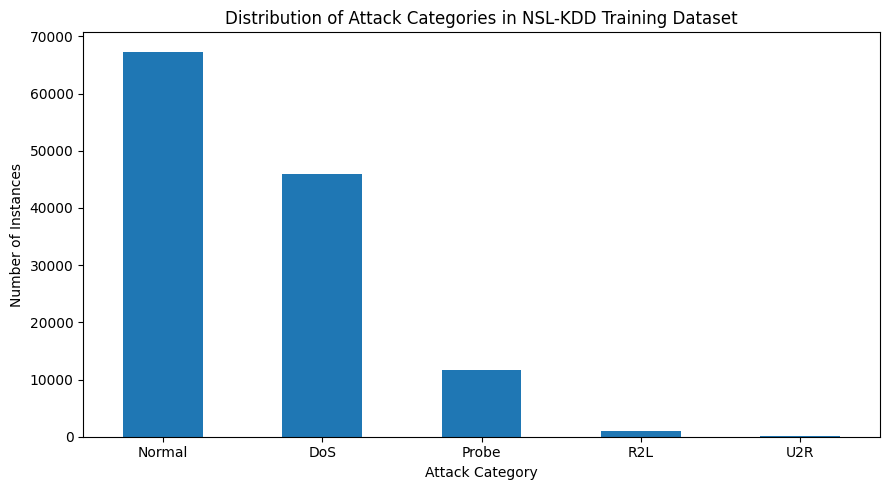

In [9]:
# ============================================================
# Exploratory Data Analysis
# Attack Category Distribution
# ============================================================

import matplotlib.pyplot as plt

# Training distribution
train_category_counts = train_df["attack_category"].value_counts()

plt.figure(figsize=(9, 5))

train_category_counts.plot(kind="bar")

plt.title("Distribution of Attack Categories in NSL-KDD Training Dataset")
plt.xlabel("Attack Category")
plt.ylabel("Number of Instances")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [10]:
# ============================================================
# Attack Category Percentage Distribution
# ============================================================

train_category_percentage = (
    train_df["attack_category"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

display(
    train_category_percentage
    .to_frame(name="Percentage")
)

,Percentage
attack_category,
Normal,53.46
DoS,36.46
Probe,9.25
R2L,0.79
U2R,0.04


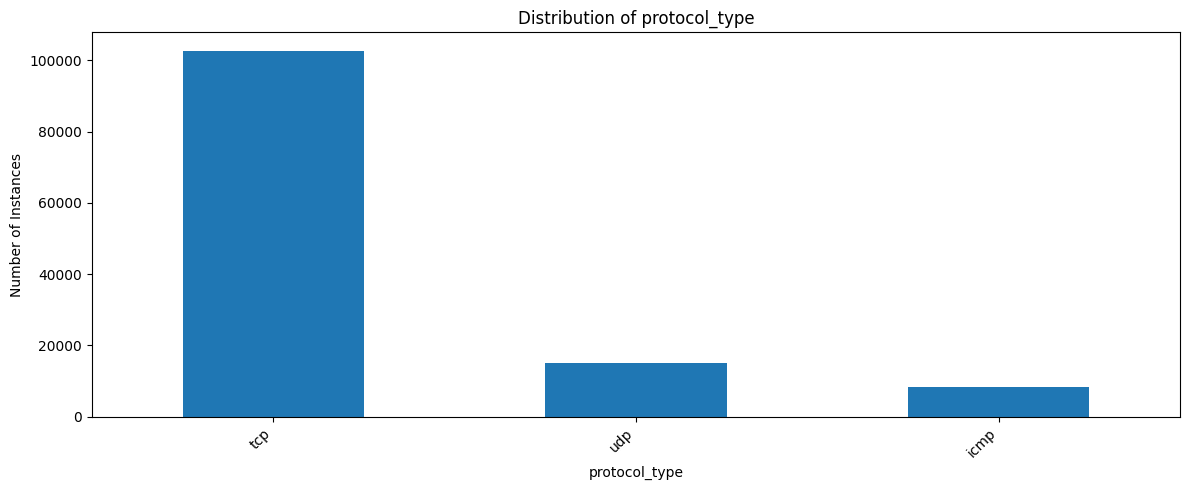

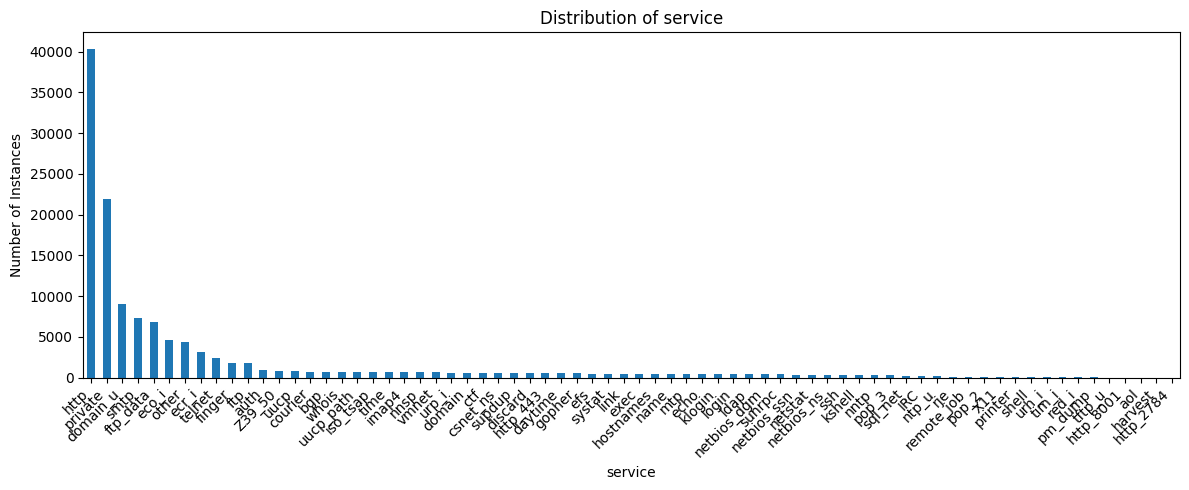

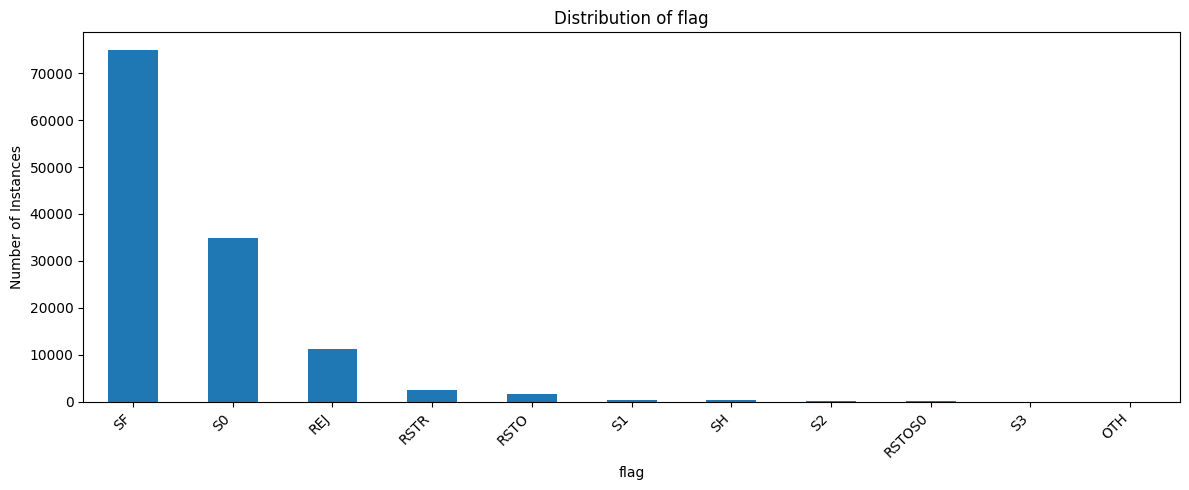

In [11]:
# ============================================================
# Categorical Feature Distributions
# ============================================================

categorical_input_features = [
    "protocol_type",
    "service",
    "flag"
]

for feature in categorical_input_features:

    plt.figure(figsize=(12, 5))

    train_df[feature].value_counts().plot(kind="bar")

    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Number of Instances")

    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

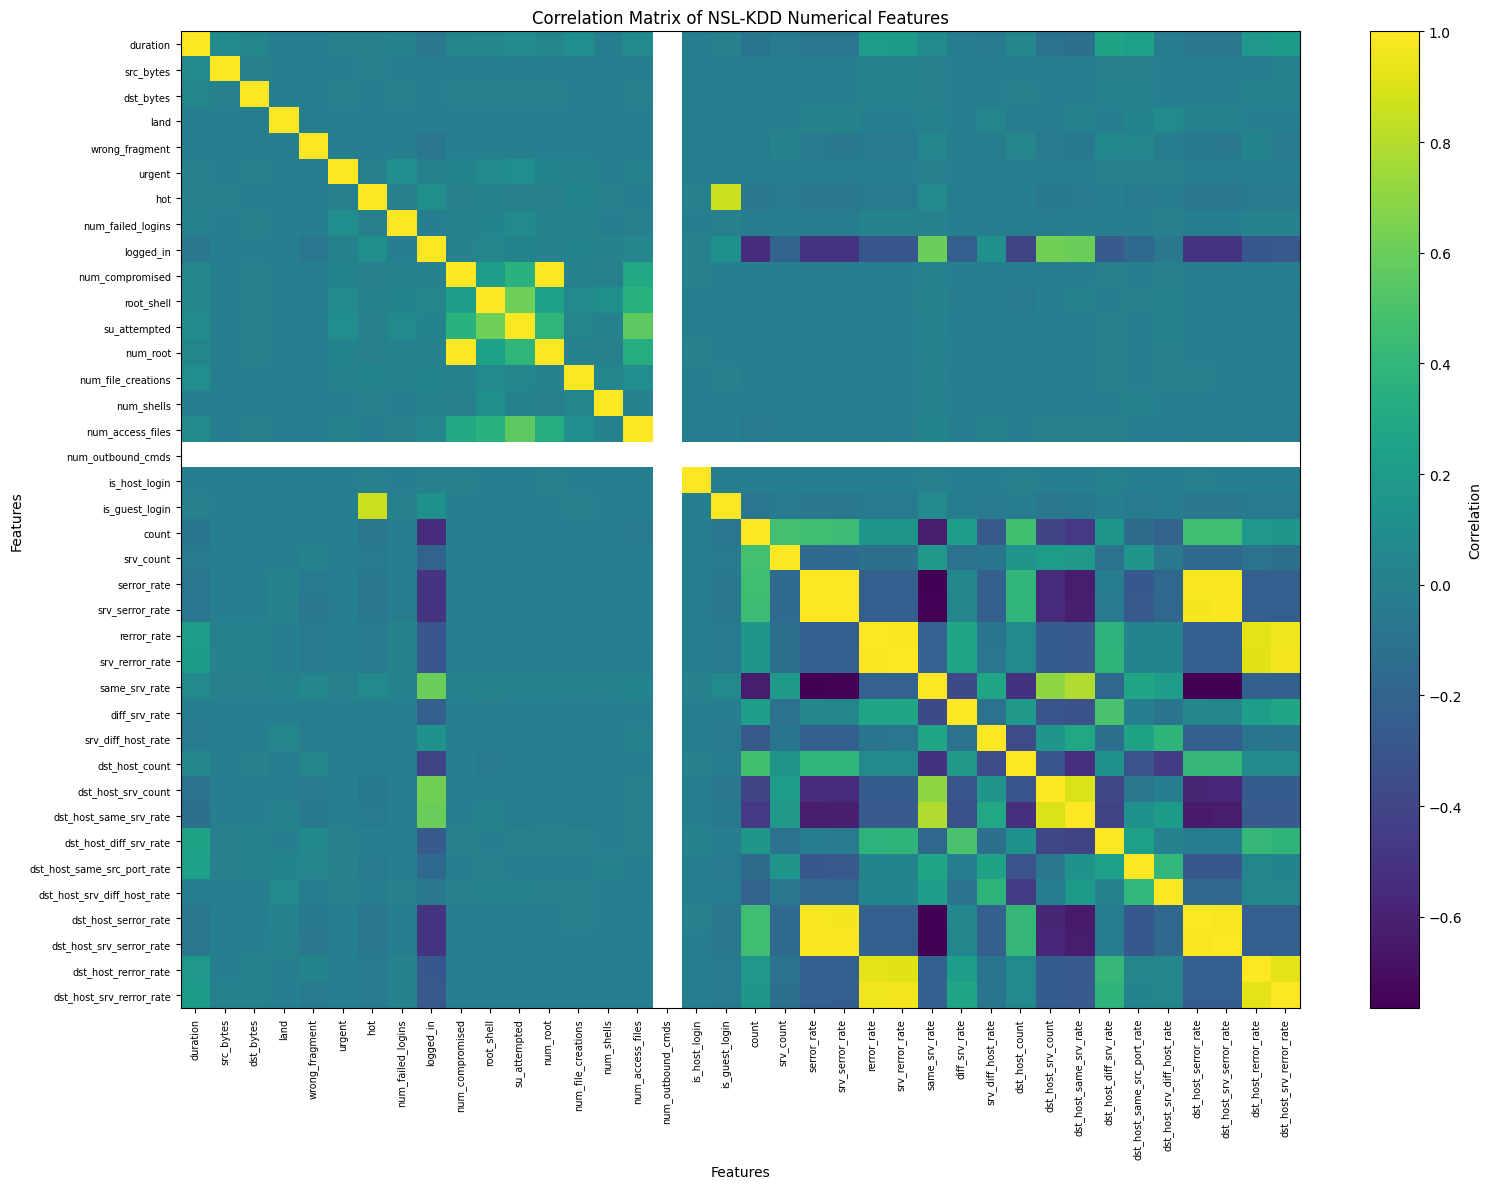

In [12]:
# ============================================================
# Correlation Analysis of Network Features
# ============================================================

import matplotlib.pyplot as plt

# Select only the 41 original network features
numeric_features = train_df[feature_names].select_dtypes(
    include=["int64", "float64"]
)

correlation_matrix = numeric_features.corr()

plt.figure(figsize=(16, 12))

plt.imshow(
    correlation_matrix,
    aspect="auto",
    interpolation="nearest"
)

plt.colorbar(label="Correlation")

plt.title("Correlation Matrix of NSL-KDD Numerical Features")
plt.xlabel("Features")
plt.ylabel("Features")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90,
    fontsize=7
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    fontsize=7
)

plt.tight_layout()
plt.show()

In [13]:
# ============================================================
# Highly Correlated Feature Pairs
# ============================================================

correlation_threshold = 0.90

high_corr_pairs = []

for i in range(len(correlation_matrix.columns)):
    for j in range(i + 1, len(correlation_matrix.columns)):

        correlation_value = correlation_matrix.iloc[i, j]

        if abs(correlation_value) >= correlation_threshold:
            high_corr_pairs.append({
                "Feature 1": correlation_matrix.columns[i],
                "Feature 2": correlation_matrix.columns[j],
                "Correlation": round(correlation_value, 4)
            })

high_corr_df = pd.DataFrame(high_corr_pairs)

if len(high_corr_df) > 0:
    high_corr_df = high_corr_df.sort_values(
        by="Correlation",
        key=lambda x: abs(x),
        ascending=False
    )

display(high_corr_df)

print(f"\nNumber of highly correlated pairs: {len(high_corr_df)}")

,Feature 1,Feature 2,Correlation
0,num_compromised,num_root,0.9988
1,serror_rate,srv_serror_rate,0.9933
6,rerror_rate,srv_rerror_rate,0.9890
5,srv_serror_rate,dst_host_srv_serror_rate,0.9863
11,dst_host_serror_rate,dst_host_srv_serror_rate,0.9851
3,serror_rate,dst_host_srv_serror_rate,0.9811
2,serror_rate,dst_host_serror_rate,0.9794
4,srv_serror_rate,dst_host_serror_rate,0.9776
10,srv_rerror_rate,dst_host_srv_rerror_rate,0.9702
8,rerror_rate,dst_host_srv_rerror_rate,0.9644



Number of highly correlated pairs: 13


In [14]:
# ============================================================
# Target Variable Preparation
# ============================================================

# Binary target:
# Normal = 0
# Attack = 1

train_df["binary_target"] = (
    train_df["attack_category"] != "Normal"
).astype(int)

test_df["binary_target"] = (
    test_df["attack_category"] != "Normal"
).astype(int)


# Multiclass target:
# Normal, DoS, Probe, R2L, U2R

multiclass_labels = {
    "Normal": 0,
    "DoS": 1,
    "Probe": 2,
    "R2L": 3,
    "U2R": 4
}

train_df["multiclass_target"] = (
    train_df["attack_category"].map(multiclass_labels)
)

test_df["multiclass_target"] = (
    test_df["attack_category"].map(multiclass_labels)
)


# Display distributions
print("=" * 60)
print("BINARY TARGET DISTRIBUTION")
print("=" * 60)

display(
    train_df["binary_target"]
    .value_counts()
    .sort_index()
    .rename(index={0: "Normal", 1: "Attack"})
    .to_frame("Count")
)


print("\n" + "=" * 60)
print("MULTICLASS TARGET DISTRIBUTION")
print("=" * 60)

display(
    train_df["multiclass_target"]
    .value_counts()
    .sort_index()
    .rename(index={
        0: "Normal",
        1: "DoS",
        2: "Probe",
        3: "R2L",
        4: "U2R"
    })
    .to_frame("Count")
)

BINARY TARGET DISTRIBUTION


,Count
binary_target,
Normal,67343
Attack,58630



MULTICLASS TARGET DISTRIBUTION


,Count
multiclass_target,
Normal,67343
DoS,45927
Probe,11656
R2L,995
U2R,52


In [15]:
# ============================================================
# Define Model Input Features
# ============================================================

# 41 original NSL-KDD network features
# Excludes:
#   - attack_type
#   - difficulty_level
#   - attack_category
#   - binary_target
#   - multiclass_target
#   - constant feature: num_outbound_cmds

model_features = [
    feature for feature in feature_names
    if feature != "num_outbound_cmds"
]

X = train_df[model_features].copy()

y_binary = train_df["binary_target"].copy()
y_multiclass = train_df["multiclass_target"].copy()

X_test = test_df[model_features].copy()

y_binary_test = test_df["binary_target"].copy()
y_multiclass_test = test_df["multiclass_target"].copy()

print("Number of model input features:", len(model_features))
print("\nModel features:")
print(model_features)

print("\nTraining feature matrix:", X.shape)
print("Testing feature matrix :", X_test.shape)

Number of model input features: 40

Model features:
['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate']

Training feature matrix: (125973, 40)
Testing feature matrix : (22544, 40)


In [16]:
# ============================================================
# Train-Validation Split
# ============================================================

from sklearn.model_selection import train_test_split

# Use the multiclass target for stratification so that
# all five attack categories are represented proportionally.

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y_multiclass,
    test_size=0.20,
    random_state=42,
    stratify=y_multiclass
)

print("Training set   :", X_train.shape)
print("Validation set :", X_val.shape)

print("\nTraining class distribution:")
display(y_train.value_counts().sort_index())

print("\nValidation class distribution:")
display(y_val.value_counts().sort_index())

Training set   : (100778, 40)
Validation set : (25195, 40)

Training class distribution:


multiclass_target
0    53874
1    36741
2     9325
3      796
4       42
Name: count, dtype: int64


Validation class distribution:


multiclass_target
0    13469
1     9186
2     2331
3      199
4       10
Name: count, dtype: int64

In [17]:
# ============================================================
# PREPROCESSING PIPELINE
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# ------------------------------------------------------------
# Identify categorical and numerical model features
# ------------------------------------------------------------

categorical_features = [
    "protocol_type",
    "service",
    "flag"
]

numerical_features = [
    feature for feature in model_features
    if feature not in categorical_features
]

print("Categorical features:")
print(categorical_features)

print("\nNumber of categorical features:", len(categorical_features))

print("\nNumber of numerical features:", len(numerical_features))


# ------------------------------------------------------------
# Numerical preprocessing
# ------------------------------------------------------------

numeric_transformer = StandardScaler()


# ------------------------------------------------------------
# Categorical preprocessing
# ------------------------------------------------------------

categorical_transformer = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=True
)


# ------------------------------------------------------------
# Combined preprocessing
# ------------------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numerical_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

print("\nPreprocessor created successfully.")

Categorical features:
['protocol_type', 'service', 'flag']

Number of categorical features: 3

Number of numerical features: 37

Preprocessor created successfully.


In [18]:
# ============================================================
# FIT PREPROCESSOR ON TRAINING DATA ONLY
# ============================================================

X_train_processed = preprocessor.fit_transform(X_train)

X_val_processed = preprocessor.transform(X_val)

X_test_processed = preprocessor.transform(X_test)

print("Original training shape   :", X_train.shape)
print("Processed training shape  :", X_train_processed.shape)

print("\nOriginal validation shape  :", X_val.shape)
print("Processed validation shape :", X_val_processed.shape)

print("\nOriginal test shape        :", X_test.shape)
print("Processed test shape       :", X_test_processed.shape)

Original training shape   : (100778, 40)
Processed training shape  : (100778, 121)

Original validation shape  : (25195, 40)
Processed validation shape : (25195, 121)

Original test shape        : (22544, 40)
Processed test shape       : (22544, 121)


In [19]:
# ============================================================
# TRANSFORMED FEATURE INSPECTION
# ============================================================

feature_names_processed = preprocessor.get_feature_names_out()

print("Total transformed features:", len(feature_names_processed))

print("\nFirst 30 transformed features:")
print(feature_names_processed[:30])

Total transformed features: 121

First 30 transformed features:
['num__duration' 'num__src_bytes' 'num__dst_bytes' 'num__land'
 'num__wrong_fragment' 'num__urgent' 'num__hot' 'num__num_failed_logins'
 'num__logged_in' 'num__num_compromised' 'num__root_shell'
 'num__su_attempted' 'num__num_root' 'num__num_file_creations'
 'num__num_shells' 'num__num_access_files' 'num__is_host_login'
 'num__is_guest_login' 'num__count' 'num__srv_count' 'num__serror_rate'
 'num__srv_serror_rate' 'num__rerror_rate' 'num__srv_rerror_rate'
 'num__same_srv_rate' 'num__diff_srv_rate' 'num__srv_diff_host_rate'
 'num__dst_host_count' 'num__dst_host_srv_count'
 'num__dst_host_same_srv_rate']


In [20]:
# ============================================================
# BINARY CLASSIFICATION - LOGISTIC REGRESSION BASELINE
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# ------------------------------------------------------------
# Create binary labels for the EXISTING train/validation split
# 0 = Normal
# 1 = Attack
# ------------------------------------------------------------

y_binary_train = y_binary.loc[X_train.index]
y_binary_val = y_binary.loc[X_val.index]

print("Binary training distribution:")
print(y_binary_train.value_counts().sort_index())

print("\nBinary validation distribution:")
print(y_binary_val.value_counts().sort_index())

# ------------------------------------------------------------
# Train Logistic Regression
# ------------------------------------------------------------

binary_lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

binary_lr.fit(
    X_train_processed,
    y_binary_train
)

# ------------------------------------------------------------
# Validation prediction
# ------------------------------------------------------------

y_val_pred_lr = binary_lr.predict(X_val_processed)

# ------------------------------------------------------------
# Evaluation
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("BINARY LOGISTIC REGRESSION - VALIDATION RESULTS")
print("=" * 60)

print(f"Accuracy : {accuracy_score(y_binary_val, y_val_pred_lr):.4f}")
print(f"Precision: {precision_score(y_binary_val, y_val_pred_lr, pos_label=1):.4f}")
print(f"Recall   : {recall_score(y_binary_val, y_val_pred_lr, pos_label=1):.4f}")
print(f"F1-score : {f1_score(y_binary_val, y_val_pred_lr, pos_label=1):.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_binary_val,
        y_val_pred_lr,
        target_names=["Normal", "Attack"]
    )
)

print("\nConfusion Matrix:")
print(confusion_matrix(y_binary_val, y_val_pred_lr))

Binary training distribution:
binary_target
0    53874
1    46904
Name: count, dtype: int64

Binary validation distribution:
binary_target
0    13469
1    11726
Name: count, dtype: int64

BINARY LOGISTIC REGRESSION - VALIDATION RESULTS
Accuracy : 0.9718
Precision: 0.9761
Recall   : 0.9631
F1-score : 0.9695

Classification Report:
              precision    recall  f1-score   support

      Normal       0.97      0.98      0.97     13469
      Attack       0.98      0.96      0.97     11726

    accuracy                           0.97     25195
   macro avg       0.97      0.97      0.97     25195
weighted avg       0.97      0.97      0.97     25195


Confusion Matrix:
[[13192   277]
 [  433 11293]]
